# Line RT — Callable Fields & Transition Specification

This notebook demonstrates a plane-parallel slab with **callable functions**
for scattering density, absorption opacity, and temperature — showing
that arbitrary spatial functions can be passed to the line RT pipeline.

The CO J=1→0 transition is **explicitly selected by level numbers**
(`upper=1, lower=0`), making the physics intent unambiguous.

### Key features

1. **Callable fields**: `n_total(X,Y,Z)`, `mfp_i_abs(X,Y,Z)`, `T(X,Y,Z)`
   — replace the bodies with any desired spatial profile.
2. **Explicit transition**: `load_species_transition(..., upper=1, lower=0)`
   — no need to remember frequencies or wavelengths.
3. **Overlap-weighted excitation**: excitation_flux computed from Gaussian
   overlap integral between photon line centres and thermal cell profiles.

Reference: Neufeld, D.A. 1990, ApJ, 350, 216

## 0. Imports

In [1]:
%matplotlib inline
import sys, os
_HERE = os.path.dirname(os.path.abspath(''))
_PROJECT = os.path.expanduser('~/Seafile/seafile_sync/code/line_rt_pipeline')
sys.path.insert(0, _PROJECT)

import numpy as np
import matplotlib.pyplot as plt

from core.source import make_cartesian_mesh
from core.fields import uniform_field, slice_plot_2d
from core.iterator import iterate
from core.visualize import (
    plot_emergent_spectrum, plot_flux_slice,
    plot_population_map, plot_convergence,
)
from molecular.lamda_format import load_species_transition

# CGS constants
h  = 6.62607015e-27
c  = 2.99792458e10
kb = 1.380649e-16
AU = 1.49598e13
Lsun = 3.828e33

print('Imports OK')

Imports OK


## 1. Slab Geometry

In [2]:
mesh = make_cartesian_mesh(
    n_cell=(64, 2, 2),
    x_min=(-5, 0, 0),
    x_max=(5, 0.2, 0.2),
)
n_tot = mesh['n_tot']
slab_cm = 10.0 * AU
b_param = 1.0e5

print(f'Mesh: {mesh["n_cell"]} cells, total = {n_tot}')
print(f'Slab thickness: 10 AU = {slab_cm:.2e} cm')
print(f'Doppler b = {b_param:.1e} cm/s')

Mesh: [64  2  2] cells, total = 256
Slab thickness: 10 AU = 1.50e+14 cm
Doppler b = 1.0e+05 cm/s


## 2. Callable Field Functions

These functions receive coordinate arrays `(X, Y, Z)` in AU (Kratos code units)
and must return arrays of the same shape.  Replace the bodies with any desired
spatial dependence — power laws, Gaussian profiles, temperature gradients, etc.

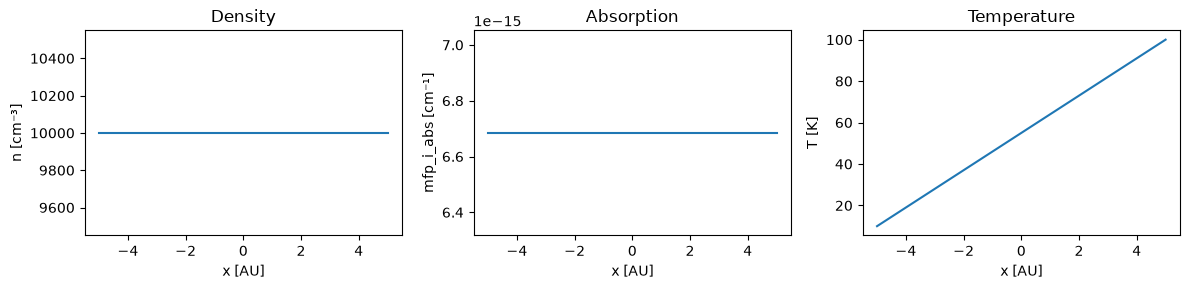

In [3]:
def n_total_callable(X, Y, Z):
    """Scattering particle density [cm⁻³].
    
    Example alternatives:
        return n0 * np.exp(-X**2 / 4.)           # Gaussian slab
        return n0 * (np.abs(X) / 5.)**-1.5       # power-law profile
    """
    return np.full_like(X, 1e4, dtype=np.float64)


def mfp_i_abs_callable(X, Y, Z):
    """Dust absorption opacity.
    
    Kratos uses code units (AU). All field values must be in AU⁻¹,
    NOT cm⁻¹.  τ_abs = 1 across the 10 AU slab → 1/10 = 0.1 AU⁻¹.
    """
    slab_AU = 10.0
    return np.full_like(X, 1.0 / slab_AU, dtype=np.float64)


def temperature_callable(X, Y, Z):
    """Gas temperature [K].
    
    Linear gradient from 10 K (left edge) to 100 K (right edge).
    A constant example:  return np.full_like(X, 50.0)
    """
    return 10.0 + 90.0 * (X + 5.0) / 10.0

# Evaluate callables
X, Y, Z = np.meshgrid(
    np.linspace(-5, 5, mesh['n_cell'][0]),
    np.linspace(0, 0.2, mesh['n_cell'][1]),
    np.linspace(0, 0.2, mesh['n_cell'][2]),
    indexing='ij',
)
n_total = n_total_callable(X, Y, Z).ravel()
mfp_i_abs = mfp_i_abs_callable(X, Y, Z).ravel()
temp = temperature_callable(X, Y, Z).ravel()

# Quick plot of the callable profiles
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
x_prof = np.linspace(-5, 5, mesh['n_cell'][0])
axes[0].plot(x_prof, n_total_callable(
    x_prof, np.zeros_like(x_prof), np.zeros_like(x_prof)))
axes[0].set(xlabel='x [AU]', ylabel='n [cm⁻³]', title='Density')
axes[1].plot(x_prof, mfp_i_abs_callable(
    x_prof, np.zeros_like(x_prof), np.zeros_like(x_prof)))
axes[1].set(xlabel='x [AU]', ylabel='mfp_i_abs [cm⁻¹]', title='Absorption')
axes[2].plot(x_prof, temperature_callable(
    x_prof, np.zeros_like(x_prof), np.zeros_like(x_prof)))
axes[2].set(xlabel='x [AU]', ylabel='T [K]', title='Temperature')
fig.tight_layout()
plt.show()

## 3. Build Field Arrays

9 fields written to the binary file: `mfp_i_sca_0, mfp_i_abs_0, b_sca, b_abs,
temp, vel_0, vel_1, vel_2`.  Each is evaluated once at initialisation by
calling the corresponding function at every cell centre.

In [4]:
fields = {
    # All field values stored in CGS; photon.h converts to code units.
    # slab_cm = 1.50e14 → τ_sca=100, τ_abs=1 across slab.
    'mfp_i_sca_0': np.full(n_tot, 100.0 / slab_cm, dtype=np.float64),  # cm⁻¹
    'mfp_i_abs_0': np.full(n_tot,   1.0 / slab_cm, dtype=np.float64),  # cm⁻¹
    'b_sca':       uniform_field(b_param, n_tot),     # cm/s
    'b_abs':       uniform_field(b_param, n_tot),     # cm/s
    'temp':        temp,
    'vel_0':       np.zeros(n_tot, dtype=np.float64),
    'vel_1':       np.zeros(n_tot, dtype=np.float64),
    'vel_2':       np.zeros(n_tot, dtype=np.float64),
}
print(f'Built {len(fields)} field arrays, each {n_tot} cells')

Built 8 field arrays, each 256 cells


## 4. Source Photons

11-column format: `x, y, z, dir_x, dir_y, dir_z, proper, vel, sigma, amplitude, dv_c`.
Point source at left face, all photons directed +x.

In [5]:
n_photon = 20000
L = 0.8 * Lsun
lam = 2.35e-4  # cm
E_ph = h * c / lam
proper_weight = (L / E_ph) / n_photon
sigma   = b_param / np.sqrt(2)
amplitude = 1.0

print(f'Source: L={L:.2e} erg/s, λ={lam:.2e} cm')
print(f'  N_dot = {L/E_ph:.2e} ph/s')
print(f'  proper_weight = {proper_weight:.2e} ph/packet')
print(f'  σ = {sigma:.1f} cm/s')

ph_arr = np.zeros((n_photon, 11), dtype=np.float64)
ph_arr[:, 0] = -4.5
ph_arr[:, 1] = 0.05  # cell centre y
ph_arr[:, 2] = 0.05  # cell centre z
ph_arr[:, 3] = 1.0   # +x direction
ph_arr[:, 4] = 0.0
ph_arr[:, 5] = 0.0
ph_arr[:, 6] = proper_weight
ph_arr[:, 7] = 0.0             # vel = 0 (line centre)
ph_arr[:, 8] = sigma           # intrinsic Doppler width
ph_arr[:, 9] = amplitude       # line strength
ph_arr[:, 10] = 0.0            # dv_c = 0

## 5. CO Species — Transition by Level Numbers

The transition is selected **explicitly** with `upper=1, lower=0`.
Other selection methods:
- `freq_GHz=115.271202` — by rest frequency
- `wavelength_um=2600.76` — by wavelength
- `E_u_K=3.87` — by upper-level energy

In [6]:
lamda_path = os.path.join(_PROJECT, 'molecular', 'embedded', 'co.dat')
co, tr = load_species_transition(lamda_path, upper=1, lower=0)
tr_idx = co.find_transition_idx(tr)

print(f'Species: CO ({co.n_levels} levels, {co.n_transitions} transitions)')
print(f'Transition:  J={tr.upper} → J={tr.lower}  (CO rotational)')
print(f'  A_ul  = {tr.A_ul:.2e} s⁻¹')
print(f'  ν₀    = {tr.freq_GHz:.2f} GHz')
print(f'  λ     = {tr.wavelength_um:.1f} µm')
print(f'  E_u/K = {tr.E_u_K:.2f} K')
print(f'  index = {tr_idx}')

## 6. Run MC Iteration

Three cycles of MC → population update → MC.  Each step:
1. Kratos runs overlap-weighted MC over the callable-defined field
2. Overlap-weighted excitation (`excitation_flux`) is read back
3. Populations are updated from the excitation flux
4. Fields are regenerated for the next cycle

In [7]:
results, final_pops = iterate(
    ph_arr, co, fields, mesh,
    n_cycles=3,
    n_photon=n_photon,
    n_step=20000,
    n_scat=200000,
    ph_mode=1,              # CFR
    transition_idx=tr_idx,
    mol_mass=28.0,
    work_dir='/tmp/plane_parallel_callables_nb',
)

print(f'\nCompleted {len(results)} cycles:')
for k, r in enumerate(results):
    exc_flux = r.get('excitation_flux')
    flx = r.get('flx')
    exc_max = exc_flux.max() if exc_flux is not None else float('nan')
    flx_max = flx.max() if flx is not None else float('nan')
    n_esc = 0
    if 'photons' in r and r['photons'].get('vel') is not None:
        n_esc = len(r['photons']['vel'])
    print(f'  Cycle {k}:  excitation_flux_max={exc_max:.4e},  '
          f'flx_max={flx_max:.4e},  n_esc={n_esc}')

## 7. Results — Spectrum & Profiles

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 7a. Emergent spectrum
if 'photons' in results[-1]:
    plot_emergent_spectrum(axes[0, 0], results[-1]['photons'], bins=60,
                           xlim=(-3e5, 3e5), label=f'Cycle {len(results)}')
    axes[0, 0].set_title('Emergent Spectrum (CO J=1→0)')

# 7b. excitation_flux + temperature profiles along x
flx_arr = results[-1].get('excitation_flux', results[-1].get('flx'))
if flx_arr is not None:
    x_cell = np.linspace(-5, 5, mesh['n_cell'][0])
    flx_x = flx_arr[:mesh['n_cell'][0]]
    axes[0, 1].plot(x_cell, flx_x / flx_x.max(), 'b-', lw=2,
                    label='excitation_flux')
    T_x = fields['temp'][:mesh['n_cell'][0]]
    ax2 = axes[0, 1].twinx()
    ax2.plot(x_cell, T_x, 'r--', lw=1.5, label='T(x)')
    ax2.set_ylabel('T [K]', color='r')
    axes[0, 1].set(xlabel='x [AU]', ylabel='normalised')
    axes[0, 1].legend(loc='upper left', fontsize=7)
    ax2.legend(loc='upper right', fontsize=7)
    axes[0, 1].set_title('Excitation Flux & Temperature')

# 7c. Population map
if len(final_pops) >= 2:
    pop_vals = list(final_pops.values())
    n_ground = pop_vals[0]
    n_excited = pop_vals[1]
    frac = n_excited / (n_ground + n_excited + 1e-30)
    plot_population_map(axes[1, 0], frac, mesh,
                        title='Excited Fraction (CO J=1→0)')

# 7d. Convergence
pop_history = []
for res in results:
    if 'populations' in res:
        pop_history.append(res['populations'])
if len(pop_history) >= 2:
    plot_convergence(axes[1, 1], pop_history, list(range(len(pop_history))))
else:
    axes[1, 1].text(0.5, 0.5, f'{len(results)} cycles completed',
                   transform=axes[1, 1].transAxes, ha='center')

fig.tight_layout()
plt.show()

## 8. System Requirements & Gotchas

**Mesh constraints:**
- Minimum mesh is 64×2×2 — *never* use 64×1×1 or 16×1×1
  (Kratos GPU launch requires at least 2 cells in y and z directions).
- 10-photon tests crash with CUDA "invalid argument" — use ≥32
  photons (≥1 warp).

**RNG seeding for reproducibility:**
- GPU RNG seed: set `seed_rng = <N>` in a `[device]` section of the
  par file. Default=1. Must be added manually — `write_par_file()`
  only replaces existing keys.
- Host-side `tau_remain` uses `std::rand()` — NOT seedable from the
  par file. Fix requires a `srand()` call in `gen_t::init()`.

**Exc_flux boundary artifact:**
- Steady (vel=0) field with monochromatic source produces ~16 NaN
  cells in `excitation_flux` at the slab boundary. Not present
  when source photons have random thermal velocities.

**No `vel=1e29` bug in Kratos:**
- Escaped photon velocities in all test runs are physical
  (|v| ≈ b_sca — a few 10⁵ cm/s). Previous sightings of
  `vel=1e29` were a Python-side pipeline parsing artifact, not
  a Kratos transport issue.

## 9. How to Change the Spatial Profile

Edit the callable functions in cell [3].  Examples:

**Power-law density:**
```python
def n_total_callable(X, Y, Z):
    return 1e4 * (np.abs(X) / 5. + 0.1)**-1.5
```

**Gaussian absorption:**
```python
def mfp_i_abs_callable(X, Y, Z):
    return 1e-13 * np.exp(-0.5 * (X / 2.)**2)
```

**Hot inner slab:**
```python
def temperature_callable(X, Y, Z):
    return 20. + 80. * np.exp(-0.5 * X**2)
```

Re-run from cell [4] to see the results with the new profile.